In [101]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
from scripts.analysis_utils import get_density2d, make_levels, add_colorbar, add_crosshair

ModuleNotFoundError: No module named 'scripts'

In [73]:
data = np.loadtxt('all_real_output.txt')
data = data[np.isin(data[:, 2], [20251113.0, 20251116.0, 20251119.0])]
print(f'Number of pointings: {len(np.unique(data[:, 0:2], axis=0))}')
print(f'Number of days: {len(np.unique(data[:, 2]))}')
print(f'Total fraction of recovered injections: {(100*len(data[data[:, -1] > 0.])/len(data)):.2f}%')
print(f'Number of injections: {len(data)}')
RA = data[:, 0]
Dec = data[:, 1]
f = data[:, 4]
DM = data[:, 5]
S = data[:, 6]
TPA_idx = data[:, 3].astype('int')
fwhm_array = np.load('../profiles/TPA_fwhm.npy')
fwhm = fwhm_array[TPA_idx]
data[:, 7] = fwhm

Number of pointings: 8651
Number of days: 3
Total fraction of recovered injections: 26.06%
Number of injections: 116234


In [74]:
RA_bins = np.arange(min(RA), max(RA), 0.5)
Dec_bins = np.arange(min(Dec), max(Dec), 0.5)
f_bins = np.logspace(np.log10(min(f)), np.log10(max(f)), 1001)
DM_bins = np.arange(min(DM), max(DM), 1.)
S_bins = np.logspace(np.log10(min(S)), np.log10(max(S)), 101)
fwhm_bins = np.logspace(np.log10(min(fwhm)), -0.95, 101)

In [76]:
RA_dev = 10
Dec_dev = 10
f_dev = 50
DM_dev = 100
S_dev = 5
FWHM_dev = 5

In [77]:
dm_f_injected, dm_f_retrieved = get_density2d(data, 5, 4, DM_bins, f_bins)
dm_f_inj_smooth = gaussian_filter(dm_f_injected, (DM_dev, f_dev))
dm_f_inj_p = dm_f_inj_smooth / np.sum(dm_f_inj_smooth)
dm_f_ret_smooth = gaussian_filter(dm_f_retrieved, (DM_dev, f_dev))
dm_f_ret_p = dm_f_ret_smooth / dm_f_inj_smooth

dm_s_injected, dm_s_retrieved = get_density2d(data, 5, 6, DM_bins, S_bins)
dm_s_inj_smooth = gaussian_filter(dm_s_injected, (DM_dev, S_dev))
dm_s_inj_p = dm_s_inj_smooth / np.sum(dm_s_inj_smooth)
dm_s_ret_smooth = gaussian_filter(dm_s_retrieved, (DM_dev, S_dev))
dm_s_ret_p = dm_s_ret_smooth / dm_s_inj_smooth

s_f_injected, s_f_retrieved = get_density2d(data, 6, 4, S_bins, f_bins)
s_f_inj_smooth = gaussian_filter(s_f_injected, (S_dev, f_dev))
s_f_inj_p = s_f_inj_smooth / np.sum(s_f_inj_smooth)
s_f_ret_smooth = gaussian_filter(s_f_retrieved, (S_dev, f_dev))
s_f_ret_p = s_f_ret_smooth / s_f_inj_smooth

s_fwhm_injected, s_fwhm_retrieved = get_density2d(data, 6, 7, S_bins, fwhm_bins)
s_fwhm_inj_smooth = gaussian_filter(s_fwhm_injected, (S_dev, FWHM_dev))
s_fwhm_inj_p = s_fwhm_inj_smooth / np.sum(s_fwhm_inj_smooth)
s_fwhm_ret_smooth = gaussian_filter(s_fwhm_retrieved, (S_dev, FWHM_dev))
s_fwhm_ret_p = s_fwhm_ret_smooth / s_fwhm_inj_smooth

dm_fwhm_injected, dm_fwhm_retrieved = get_density2d(data, 5, 7, DM_bins, fwhm_bins)
dm_fwhm_inj_smooth = gaussian_filter(dm_fwhm_injected, (DM_dev, FWHM_dev))
dm_fwhm_inj_p = dm_fwhm_inj_smooth / np.sum(dm_fwhm_inj_smooth)
dm_fwhm_ret_smooth = gaussian_filter(dm_fwhm_retrieved, (DM_dev, FWHM_dev))
dm_fwhm_ret_p = dm_fwhm_ret_smooth / dm_fwhm_inj_smooth

fwhm_f_injected, fwhm_f_retrieved = get_density2d(data, 7, 4, fwhm_bins, f_bins)
fwhm_f_inj_smooth = gaussian_filter(fwhm_f_injected, (FWHM_dev, f_dev))
fwhm_f_inj_p = fwhm_f_inj_smooth / np.sum(fwhm_f_inj_smooth)
fwhm_f_ret_smooth = gaussian_filter(fwhm_f_retrieved, (FWHM_dev, f_dev))
fwhm_f_ret_p = fwhm_f_ret_smooth / fwhm_f_inj_smooth

dm_fwhm_inj_p[np.isnan(dm_fwhm_inj_p)] = 1e-16
dm_fwhm_inj_p[dm_fwhm_inj_p == 0] = 1e-16
dm_fwhm_ret_p[np.isnan(dm_fwhm_ret_p)] = 0.00041
dm_fwhm_ret_p[dm_fwhm_ret_p == 0] = 0.00041

/tmp/ipykernel_643858/3449727290.py:5: RuntimeWarning: invalid value encountered in divide
  dm_f_ret_p = dm_f_ret_smooth / dm_f_inj_smooth
/tmp/ipykernel_643858/3449727290.py:11: RuntimeWarning: invalid value encountered in divide
  dm_s_ret_p = dm_s_ret_smooth / dm_s_inj_smooth
/tmp/ipykernel_643858/3449727290.py:29: RuntimeWarning: invalid value encountered in divide
  dm_fwhm_ret_p = dm_fwhm_ret_smooth / dm_fwhm_inj_smooth


/tmp/ipykernel_643858/399517736.py:4: UserWarning: Log scale: values of z <= 0 have been masked
  cf0 = axes[0, 0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_inj_p,
/tmp/ipykernel_643858/399517736.py:16: UserWarning: Log scale: values of z <= 0 have been masked
  cf1 = axes[0, 1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_inj_p,


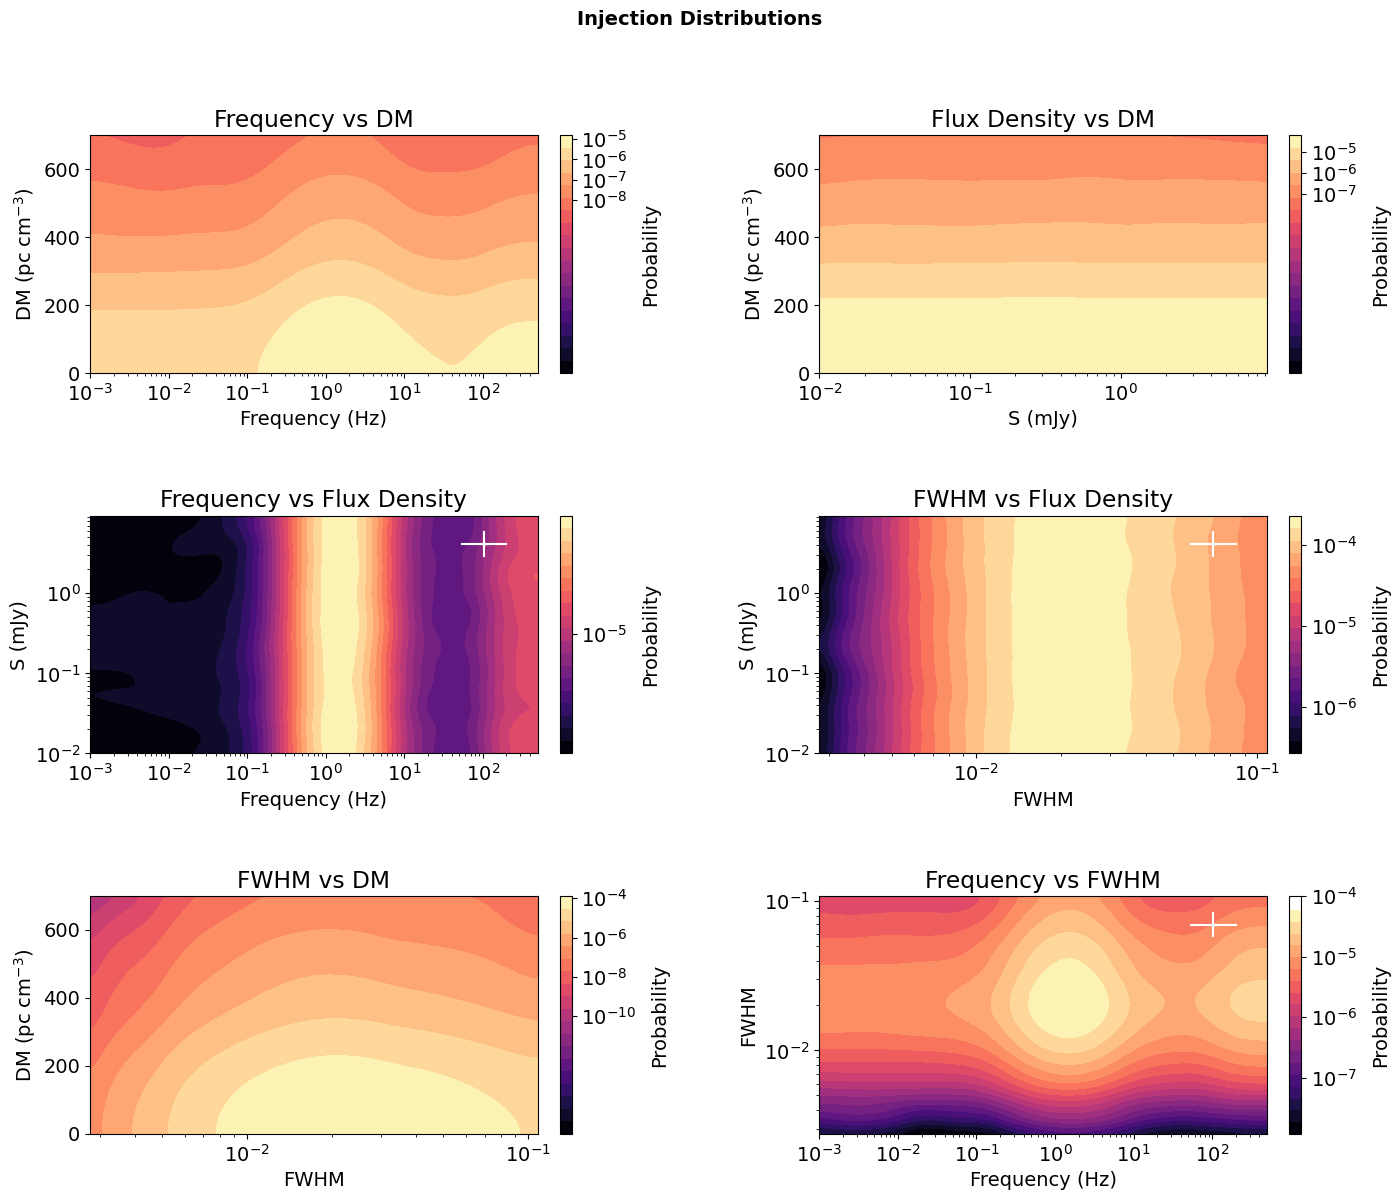

In [102]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)

#f vs DM
cf0 = axes[0, 0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_inj_p, 
                           levels=make_levels(dm_f_inj_p, logspace = True), 
                           norm=LogNorm(), cmap='magma')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Frequency (Hz)')
axes[0, 0].set_ylabel(r'DM (pc cm$^{-3}$)')
axes[0, 0].set_title('Frequency vs DM')
axes[0, 0].set_ylim(0, 700)
add_colorbar(fig, axes[0, 0], cf0, tick_locs=[1e-8, 1e-7, 1e-6, 1e-5])
add_crosshair(axes[0, 0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = axes[0, 1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_inj_p, 
                           levels=make_levels(dm_s_inj_p, logspace = True),
                             norm=LogNorm(), cmap='magma')
axes[0, 1].set_xscale('log')
axes[0, 1].set_xlabel('S (mJy)')
axes[0, 1].set_ylabel(r'DM (pc cm$^{-3}$)')
axes[0, 1].set_title('Flux Density vs DM')
axes[0, 1].set_ylim(0, 700)
add_colorbar(fig, axes[0, 1], cf1, tick_locs=[1e-7, 1e-6, 1e-5])
add_crosshair(axes[0, 1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = axes[1, 0].contourf(f_bins[:-1], S_bins[:-1], s_f_inj_p, 
                           levels=make_levels(s_f_inj_p, logspace = True), 
                           norm=LogNorm(), cmap='magma')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('S (mJy)')
axes[1, 0].set_title('Frequency vs Flux Density')
add_colorbar(fig, axes[1, 0], cf2, tick_locs=[1e-5])
add_crosshair(axes[1, 0], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = axes[1, 1].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_inj_p, 
                           levels=make_levels(s_fwhm_inj_p, logspace = True), 
                           norm=LogNorm(), cmap='magma')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_xlabel('FWHM')
axes[1, 1].set_ylabel('S (mJy)')
axes[1, 1].set_title('FWHM vs Flux Density')
add_colorbar(fig, axes[1, 1], cf3, tick_locs=[1e-6, 1e-5, 1e-4])
add_crosshair(axes[1, 1], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = axes[2, 0].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_inj_p, 
                           levels=make_levels(dm_fwhm_inj_p, logspace = True), 
                           norm=LogNorm(), cmap='magma')
axes[2, 0].set_xscale('log')
axes[2, 0].set_xlabel('FWHM')
axes[2, 0].set_ylabel(r'DM (pc cm$^{-3}$)')
axes[2, 0].set_title('FWHM vs DM')
axes[2, 0].set_ylim(0, 700)
add_colorbar(fig, axes[2, 0], cf4, tick_locs=[1e-10, 1e-8, 1e-6, 1e-4])
add_crosshair(axes[2, 0], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = axes[2, 1].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_inj_p, 
                           levels=make_levels(fwhm_f_inj_p, logspace = True), 
                           norm=LogNorm(), cmap='magma')
axes[2, 1].set_xscale('log')
axes[2, 1].set_yscale('log')
axes[2, 1].set_xlabel('Frequency (Hz)')
axes[2, 1].set_ylabel('FWHM')
axes[2, 1].set_title('Frequency vs FWHM')
add_colorbar(fig, axes[2, 1], cf5, tick_locs=[1e-7, 1e-6, 1e-5, 1e-4])
add_crosshair(axes[2, 1], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

fig.suptitle('Injection Distributions', fontsize=14, fontweight='bold')
fig.get_layout_engine().set(h_pad=0.1, hspace=0.15, w_pad=0.1, wspace=0.1, 
                            rect=[0, 0, 1, 0.95])
plt.show()

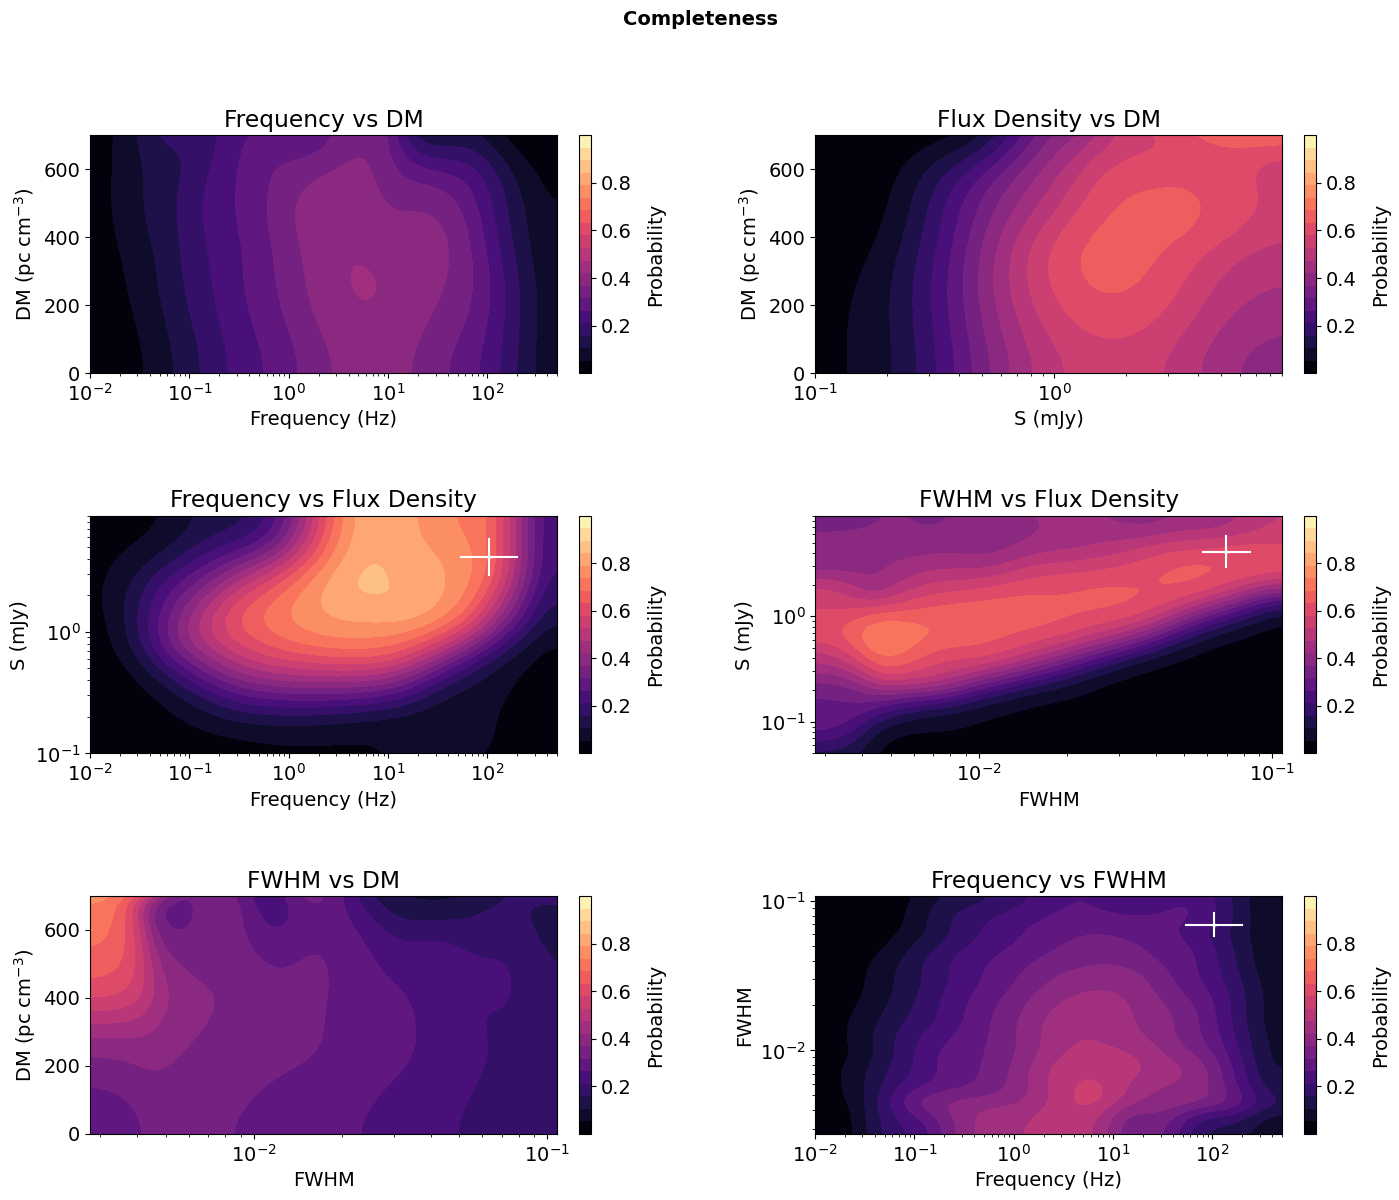

In [103]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)

#f vs DM
cf0 = axes[0, 0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_ret_p, 
                           levels=make_levels(dm_f_ret_p),cmap='magma')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Frequency (Hz)')
axes[0, 0].set_ylabel(r'DM (pc cm$^{-3}$)')
axes[0, 0].set_title('Frequency vs DM')
axes[0, 0].set_xlim(1e-2, max(f_bins))
axes[0, 0].set_ylim(0, 700)
add_colorbar(fig, axes[0, 0], cf0, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[0, 0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = axes[0, 1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_ret_p, 
                           levels=make_levels(dm_s_ret_p), cmap='magma')
axes[0, 1].set_xscale('log')
axes[0, 1].set_xlabel('S (mJy)')
axes[0, 1].set_ylabel(r'DM (pc cm$^{-3}$)')
axes[0, 1].set_title('Flux Density vs DM')
axes[0, 1].set_xlim(1e-1, max(S_bins) - 1)
axes[0, 1].set_ylim(0, 700)
add_colorbar(fig, axes[0, 1], cf1, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[0, 1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = axes[1, 0].contourf(f_bins[:-1], S_bins[:-1], s_f_ret_p, 
                           levels=make_levels(s_f_ret_p), cmap='magma')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('S (mJy)')
axes[1, 0].set_title('Frequency vs Flux Density')
axes[1, 0].set_xlim(1e-2, max(f_bins))
axes[1, 0].set_ylim(1e-1, max(S_bins) - 1)
add_colorbar(fig, axes[1, 0], cf2, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[1, 0], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = axes[1, 1].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_ret_p, 
                           levels=make_levels(s_fwhm_ret_p), cmap='magma')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_xlabel('FWHM')
axes[1, 1].set_ylabel('S (mJy)')
axes[1, 1].set_title('FWHM vs Flux Density')
axes[1, 1].set_ylim(5e-2, max(S_bins) -1 )
add_colorbar(fig, axes[1, 1], cf3, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[1, 1], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = axes[2, 0].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_ret_p, 
                           levels=make_levels(dm_fwhm_ret_p), cmap='magma')
axes[2, 0].set_xscale('log')
axes[2, 0].set_xlabel('FWHM')
axes[2, 0].set_ylabel(r'DM (pc cm$^{-3}$)')
axes[2, 0].set_title('FWHM vs DM')
axes[2, 0].set_ylim(0, 700)
add_colorbar(fig, axes[2, 0], cf4, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[2, 0], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = axes[2, 1].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_ret_p, 
                           levels=make_levels(fwhm_f_ret_p), cmap='magma')
axes[2, 1].set_xscale('log')
axes[2, 1].set_yscale('log')
axes[2, 1].set_xlabel('Frequency (Hz)')
axes[2, 1].set_ylabel('FWHM')
axes[2, 1].set_title('Frequency vs FWHM')
axes[2, 1].set_xlim(1e-2, max(f_bins))
add_colorbar(fig, axes[2, 1], cf5, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[2, 1], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

fig.suptitle('Completeness', fontsize=14, fontweight='bold')
fig.get_layout_engine().set(h_pad=0.1, hspace=0.15, w_pad=0.1, wspace=0.1, 
                            rect=[0, 0, 1, 0.95])
plt.show()

Everything below this is extremely work in progress...

In [ ]:
def gradient_correlation(data, x_bins, y_bins, x_log=False, y_log=False):

    x = np.log(x_bins[:-1]) if x_log else x_bins[:-1]
    y = np.log(y_bins[:-1]) if y_log else y_bins[:-1]

    grad_y, grad_x = np.gradient(data, y, x)
    
    gx = grad_x.ravel()
    gy = grad_y.ravel()
    mask = np.isfinite(gx) & np.isfinite(gy)
    
    r = np.corrcoef(gx[mask], gy[mask])[0, 1]
    return r, grad_x, grad_y

pairs = [
    ('Frequency', 'DM',        dm_f_ret_p,   f_bins,    DM_bins,   True,  False),
    ('S',         'DM',        dm_s_ret_p,   S_bins,    DM_bins,   True,  False),
    ('Frequency', 'S',         s_f_ret_p,    f_bins,    S_bins,    True,  True),
    ('FWHM',      'S',         s_fwhm_ret_p, fwhm_bins, S_bins,    True,  True),
    ('FWHM',      'DM',        dm_fwhm_ret_p,fwhm_bins, DM_bins,   True,  False),
    ('Frequency', 'FWHM',      fwhm_f_ret_p, f_bins,    fwhm_bins, True,  True),
]

print(f"{'Parameter Pair':<25} {'Gradient Correlation':>20}")
print("-" * 47)
for x_name, y_name, data, x_bins_, y_bins_, x_log, y_log in pairs:
    r, _, _ = gradient_correlation(data, x_bins_, y_bins_, x_log, y_log)
    print(f"{x_name + ' vs ' + y_name:<25} {r:>20.4f}")

Parameter Pair            Gradient Correlation
-----------------------------------------------
Frequency vs DM                         0.2463
S vs DM                                -0.4593
Frequency vs S                         -0.3941
FWHM vs S                              -0.6556
FWHM vs DM                              0.1934
Frequency vs FWHM                      -0.1181


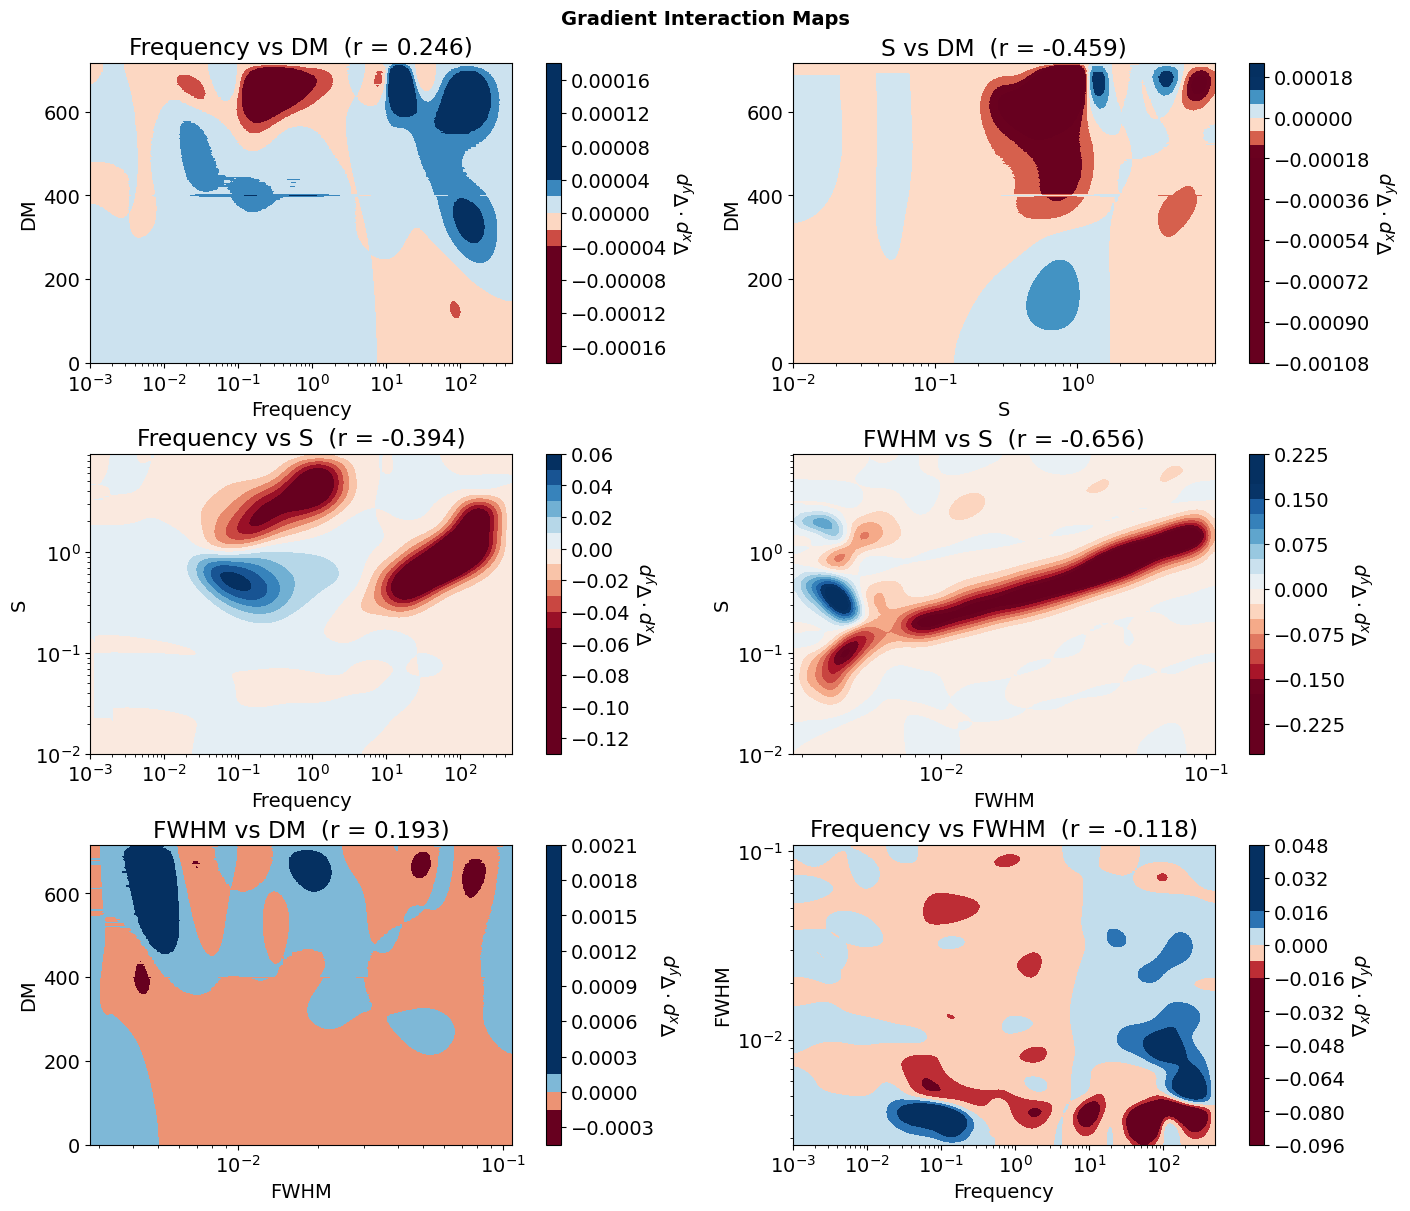

In [104]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)

for ax, (x_name, y_name, data, x_bins_, y_bins_, x_log, y_log) in zip(axes.ravel(), pairs):
    r, grad_x, grad_y = gradient_correlation(data, x_bins_, y_bins_, x_log, y_log)
    interaction = grad_x * grad_y
    x_vals = x_bins_[:-1]
    y_vals = y_bins_[:-1]
    
    vmax = np.nanpercentile(np.abs(interaction), 95)
    cf = ax.contourf(x_vals, y_vals, interaction, levels=20, 
                     cmap='RdBu', vmin=-vmax, vmax=vmax)
    fig.colorbar(cf, ax=ax, label='$\\nabla_x p \\cdot \\nabla_y p$')
    
    if x_log: ax.set_xscale('log')
    if y_log: ax.set_yscale('log')
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_title(f'{x_name} vs {y_name}  (r = {r:.3f})')

fig.suptitle('Gradient Interaction Maps', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
skymap_injected, skymap_retrieved = get_density2d(data, 5, 4, RA_bins, Dec_bins)
skymap_inj_smooth = gaussian_filter(skymap_injected, (RA_dev, Dec_dev))
skymap_inj_p = skymap_inj_smooth / np.sum(skymap_inj_smooth)
skymap_ret_smooth = gaussian_filter(skymap_retrieved, (RA_dev, Dec_dev))
skymap_ret_p = skymap_ret_smooth / skymap_inj_smooth

skymap_ret_p[np.isnan(skymap_ret_p)] = 0.


fig, ax = plt.subplots(1)

cf = ax.contourf(RA_bins[:-1], Dec_bins[:-1], skymap_ret_p.T, levels=make_levels(skymap_ret_p), 
                 cmap='magma')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')
add_colorbar(fig, ax, cf, skymap_ret_p, tick_locs=[0, 0.2, 0.4, 0.6, 0.8])
add_crosshair(ax, RA_bins, Dec_bins, RA_dev, Dec_dev, x_log=False)